In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file = r"../Dataset/Cleaned_Academic_Probation_Project.xlsx"

df = pd.read_excel(
    file,
    sheet_name="Master_Education_Data (2)"
)

print(df.shape)

(10000, 16)


In [3]:
df['Last_Login_Date'] = pd.to_datetime(
    df['Last_Login_Date']
)

latest_date = df['Last_Login_Date'].max()

df['Recency'] = (
    latest_date - df['Last_Login_Date']
).dt.days

In [4]:
rfm = df[[
    'Student_ID',
    'Recency',
    'LMS_Login_Count',
    'Study_Hours_Per_Week'
]]

rfm.columns = [
    'Student_ID',
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,Student_ID,Recency,Frequency,Monetary
0,S0001,337,41,35
1,S0002,34,234,29
2,S0003,72,3,3
3,S0004,147,3,17
4,S0005,178,166,2


In [5]:
rfm.describe()

,Recency,Frequency,Monetary
count,10000.000000,10000.000000,10000.000000
mean,283.781000,80.246300,20.171400
std,145.250031,49.429726,11.425107
min,0.000000,1.000000,1.000000
25%,159.000000,39.000000,10.000000
50%,280.000000,78.000000,20.000000
75%,408.000000,118.000000,30.000000
max,545.000000,250.000000,40.000000


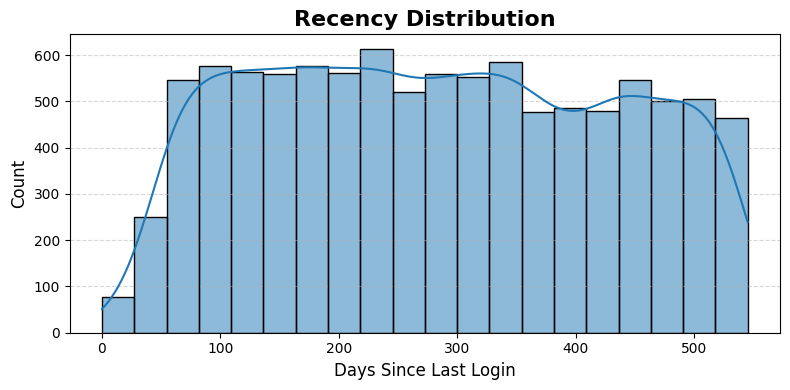

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.histplot(
    rfm['Recency'],
    bins=20,
    kde=True,
    edgecolor='black'
)

plt.title(
    "Recency Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    "Days Since Last Login",
    fontsize=12
)

plt.ylabel(
    "Count",
    fontsize=12
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    "Output_Charts/Recency_Distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()



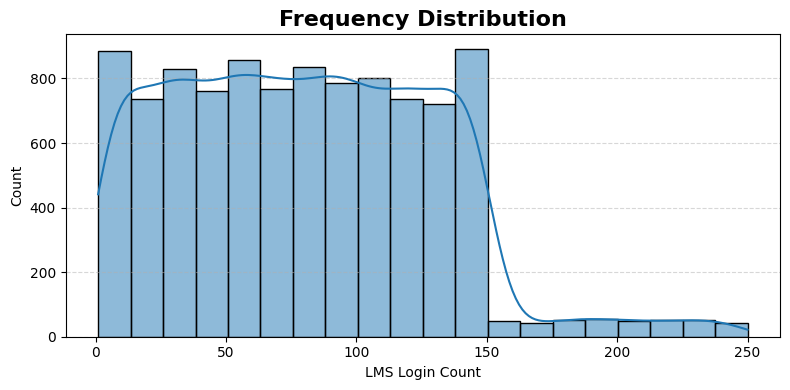

In [8]:
plt.figure(figsize=(8,4))

sns.histplot(
    rfm['Frequency'],
    bins=20,
    kde=True,
    edgecolor='black'
)

plt.title(
    "Frequency Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("LMS Login Count")
plt.ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(
    "Output_Charts/Frequency_Distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

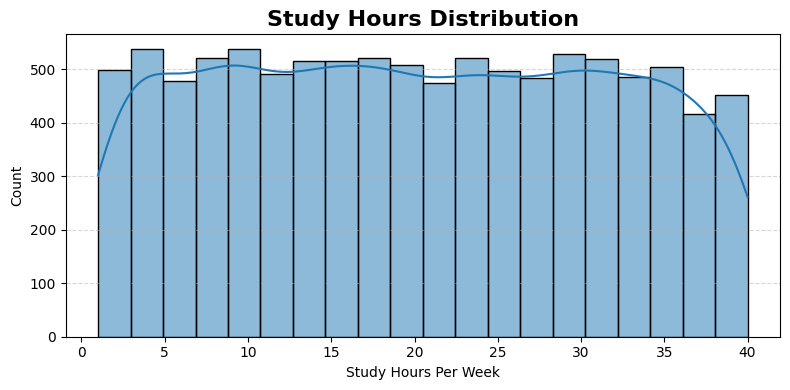

In [7]:
plt.figure(figsize=(8,4))

sns.histplot(
    rfm['Monetary'],
    bins=20,
    kde=True,
    edgecolor='black'
)

plt.title(
    "Study Hours Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Study Hours Per Week")
plt.ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(
    "Output_Charts/Monetary_Distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [9]:
rfm['Segment'] = 'Average'

# High Performers
rfm.loc[
    (rfm['Frequency'] >= 118) &
    (rfm['Monetary'] >= 30) &
    (rfm['Recency'] <= 159),
    'Segment'
] = 'High Performer'

# At Risk Students
rfm.loc[
    (rfm['Frequency'] <= 39) &
    (rfm['Monetary'] <= 10) &
    (rfm['Recency'] >= 408),
    'Segment'
] = 'At Risk'

rfm.head()

C:\Users\harih\AppData\Local\Temp\ipykernel_37112\179064902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm['Segment'] = 'Average'


,Student_ID,Recency,Frequency,Monetary,Segment
0,S0001,337,41,35,Average
1,S0002,34,234,29,Average
2,S0003,72,3,3,Average
3,S0004,147,3,17,Average
4,S0005,178,166,2,Average


In [10]:
rfm['Segment'].value_counts()

Segment
Average           9629
At Risk            186
High Performer     185
Name: count, dtype: int64

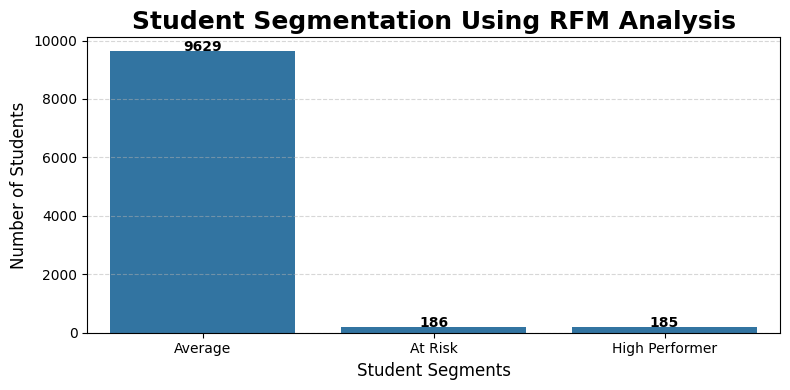

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

segment_counts = (
    rfm['Segment']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,4))

ax = sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title(
    "Student Segmentation Using RFM Analysis",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Student Segments",
    fontsize=12
)

plt.ylabel(
    "Number of Students",
    fontsize=12
)

for i, value in enumerate(segment_counts.values):
    plt.text(
        i,
        value + 20,
        str(value),
        ha='center',
        fontweight='bold'
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    "Output_Charts/Student_Segments.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [15]:
rfm.to_excel(
    "Processed_Data/Student_RFM.xlsx",
    index=False
)

print("RFM dataset saved successfully")

RFM dataset saved successfully
